# Home assigment 1

Please give your name below:

In [ ]:
name='Lovisa'

## Exercise 2

When you enter a nuclear physics lab, you often find a nice [nuclide chart](https://en.wikipedia.org/wiki/Table_of_nuclides) on the wall. Now we will try to make our own, where we color the nuclides according to the average binding energy of the nuclides.

Along this home assignment you find a file called 'HA1-relmass.txt' (downloaded from https://www.nist.gov/pml/atomic-weights-and-isotopic-compositions-relative-atomic-masses
). This contains a list of several nuclides in the following format:

```
    Atomic Number = 1
    Atomic Symbol = H
    Mass Number = 1
    Relative Atomic Mass = 1.00782503223(9)
    Isotopic Composition = 0.999885(70)
    Standard Atomic Weight = [1.00784,1.00811]
    Notes = m
```

Your task is going to be to 

- extract the information from the file 'HA1-relmass.txt' with python. Your interest will be the atomic number, symbol, mass number and relative atomic mass. Arrange the data into a dictionary of dictionaries, where the keys of the main dictionary are formatted as `symbolA` (eg. `H1`,`U235`), and the keys of the subdictionaries are `Z`, `A`, `m`). Thus the dictionary will look like:

```
    isotopes={'H1': {'Z': 1,'A': 1,'m': 1.00782503223},
              'D2': {'Z': 1,'A': 2,'m': 2.01410177812}
               ...}
```

- During the datalab you have written a function to calculate the average binding energy per nucleon. Use this function to calculate the binding energy of each nuclide, and include this information as another entry with key `'eps'` in the subdictionaries.

```
    isotopes={...,
              'D2': {'Z': 1,'A': 2,'m': 2.01410177812, 'eps': 1.1122897908460128},
               ...}
```

- Find out which nuclide has the highest binding energy per nucleon.
- Create a 2D numpy array called `NZ` which has 119 rows (the highest atomic number) and 178 columns (the highest neutron number). Fill it up with the binding energy per nucleon value.
- Plot the content of `NZ` with `plt.imshow()`. (hint: for N-Z pairs for which no known nuclide exists you probably allocated 0.0 as the binding energy. The default colormap of matplotlib will color these values as blue. If you want these values to be colored white you can convert all 0.0 values to `np.nan`.)

In [39]:
def BAZ(A,Z,m):
    """Function to calculate the binding energy per nucleon
    
    Parameters
    ----------
    A : int
        Mass number of nuclide
    Z : int
        Proton number of nuclide
    m : float
        Mass of the nuclide
    """
    me=5.48579909070e-4 #u
    mn=1.00866491588    #u
    mp=1.007276466621   #u
    muc2=931.49410242 #MeV
    
    eps=(Z*mp + (A-Z)*mn - m)*muc2
    return eps/A

In [49]:
import re
import numpy as np
import matplotlib.pyplot as plt

with open('HA1-relmass.txt', 'r') as file:
    isotopes_data = file.read()
list_isotopes = isotopes_data.strip().split('\n\n') # Separated in one item per isotope

isotopes = {}
for isotope in list_isotopes:
    properties = re.split('\n', isotope)
    symbol = re.search(r'=\s*(\w+)', properties[1]).group(1)
    mass_number = re.search(r'=\s*(\d+)', properties[2]).group(1)
    Z = int(re.search(r'=\s*(\d+)', properties[0]).group(1))
    m = float(re.search(r'=\s*(\d+\.?\d*)', properties[3]).group(1))
    isotopes[f'{symbol}{mass_number}'] = {'Z': Z, 'A': int(mass_number), 'm': m, 'eps': BAZ(int(mass_number),Z,m)}


# Max binding energy per nucleon
def calc_max_BE(isotopes):
    eps_max = (None, float('-inf'))
    for symbol, isotope_properties in isotopes.items():
        eps = isotope_properties['eps']
        if eps > eps_max[1]:
            eps_max = (symbol, eps)
    return eps_max
print(calc_max_BE(isotopes))


''' Max binding energy per nucleon (using built in function max)
max_nuclide = max(isotopes, key=lambda k: isotopes[k]['eps'])
max_eps = isotopes[max_nuclide]['eps']
print(f'{max_nuclide}: {max_eps}')
'''


        


('Ni62', 8.563778700840052)


" Max binding energy per nucleon (using built in function max)\nmax_nuclide = max(isotopes, key=lambda k: isotopes[k]['eps'])\nmax_eps = isotopes[max_nuclide]['eps']\nprint(f'{max_nuclide}: {max_eps}')\n"

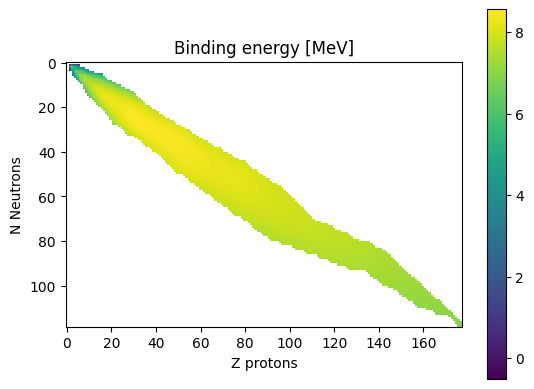

In [76]:
NZ = np.full((119, 178), np.nan)
for isotope in isotopes.values():
    NZ[isotope['Z'], isotope['A'] - isotope['Z']] = isotope['eps']

plt.figure()
plt.imshow(NZ)
plt.xlabel('Z protons')
plt.ylabel('N Neutrons')
plt.title('Binding energy [MeV]')
plt.colorbar()
plt.show()

